CPU USAGE vs BATTERY POWER ANALYSIS
=== Filter Summary ===
Brightness range: 153 ~ 204 (i.e., 20%~40% of 255)
CPU Usage range: 20% ~ 50%
Rows kept: 664 / 86399

CPU Usage stats:
count    664.000000
mean      50.781627
std        5.934959
min       29.000000
25%       46.000000
50%       51.000000
75%       56.000000
max       60.000000
Name: cpu_usage, dtype: float64

Battery_power stats:
count    664.000000
mean      -2.057606
std        0.394917
min       -3.466299
25%       -2.284999
50%       -2.069605
75%       -1.839084
max       -0.848029
Name: battery_power, dtype: float64

Saved to: /content/filtered_cpu_battery_data.csv


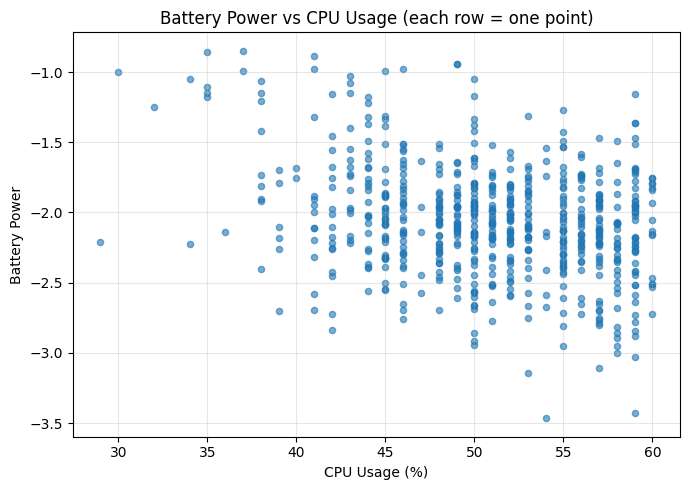

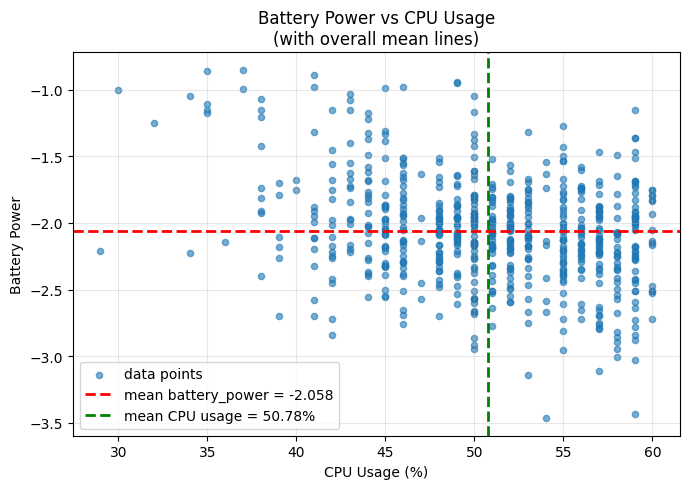


Overall Mean Battery Power: -2.058

=== CPU Usage Statistics ===
Mean   CPU Usage : 50.78%
Median CPU Usage : 51.00%
Std    CPU Usage : 5.93%
Min    CPU Usage : 29.00%
Max    CPU Usage : 60.00%

=== Battery Power Statistics ===
Mean   battery_power : -2.058
Median battery_power : -2.070
Std    battery_power : 0.395
Min    battery_power : -3.466
Max    battery_power : -0.848

=== Correlation Analysis ===
Correlation between CPU Usage and Battery Power: -0.298
This indicates a weak negative correlation.
Interpretation: Higher CPU usage is associated with lower battery power.


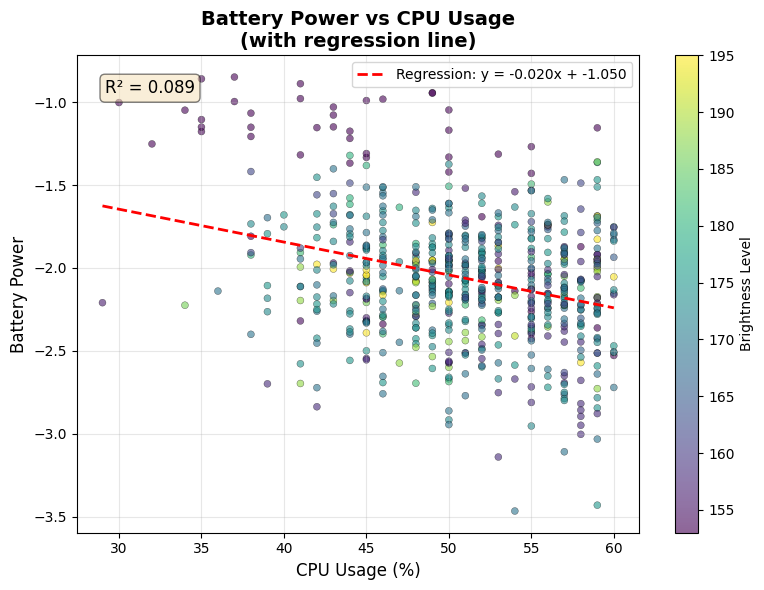


DATA PREVIEW
Total filtered rows: 664

First 10 rows:
       cpu_usage  battery_power  bright_level
44992         59      -1.919478           153
44993         56      -2.244090           153
44994         60      -2.527935           153
44995         54      -2.138553           153
44997         58      -1.871472           153
44998         50      -1.798701           153
44999         59      -2.361438           153
45002         55      -2.262911           153
45004         46      -2.338742           153
45005         52      -1.690802           153

ANALYSIS COMPLETE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_filtered_rows(
    csv_path: str,
    out_path: str = None,
    encoding: str = "utf-8"
):
    # =========================
    # 1) Read CSV
    # =========================
    df = pd.read_csv(csv_path, encoding=encoding, low_memory=False)

    # =========================
    # 2) Column name compatibility
    # =========================
    def norm(s: str) -> str:
        s = str(s).strip().lower()
        s = s.replace("—", "-").replace("–", "-")  # Handle different dash types
        s = s.replace(" ", "_")
        s = s.replace("-", "_")
        return s

    col_map = {norm(c): c for c in df.columns}

    # Required standard column names -> possible aliases (after normalization)
    need = {
        "bright_level": ["bright_level", "brightness", "screen_brightness", "brightlevel"],
        "cpu_usage": ["cpu_usage", "cpuusage", "cpu_use", "cpu_util", "cpu_utilization", "cpu"],
        "gps_status": ["gps_status", "gps", "gpsstatus"],
        "screen_status": ["screen_status", "screen", "screenstatus"],
        "battery_charging_status": ["battery_charging_status", "charging_status", "batterychargingstatus"],
        "battery_connection_status": ["battery_connection_status", "connection_status", "batteryconnectionstatus"],
        "battery_power": ["battery_power", "power", "battery_power_w", "batterypower"],
    }

    # Find actual column names
    actual = {}
    missing = []
    for std_name, aliases in need.items():
        found = None
        for a in aliases:
            if a in col_map:
                found = col_map[a]
                break
        if found is None:
            missing.append(std_name)
        else:
            actual[std_name] = found

    if missing:
        raise KeyError(
            "Missing required columns in CSV (or column name mismatch):\n"
            + "\n".join(missing)
            + "\n\nCurrent CSV column names:\n"
            + ", ".join(df.columns[:50]) + (" ..." if len(df.columns) > 50 else "")
        )

    # =========================
    # 3) Convert to numeric (avoid string comparison issues)
    # =========================
    for k in actual:
        df[actual[k]] = pd.to_numeric(df[actual[k]], errors="coerce")

    # =========================
    # 4) Calculate brightness range corresponding to 20%~40% of 255
    # =========================
    bmin = int(np.ceil(0.20 * 255))  # 51
    bmax = int(np.floor(0.40 * 255))  # 102

    # =========================
    # 5) Filter conditions
    # =========================
    mask = (
        df[actual["bright_level"]].between(bmin, bmax, inclusive="both") &
        df[actual["cpu_usage"]].between(20, 60, inclusive="both") &
        (df[actual["gps_status"]] == 3) &
        (df[actual["screen_status"]] == 1) &
        (df[actual["battery_charging_status"]] == 3) &
        (df[actual["battery_connection_status"]] == 0)
    )

    df_f = df.loc[mask, [
        actual["bright_level"],
        actual["cpu_usage"],
        actual["gps_status"],
        actual["screen_status"],
        actual["battery_charging_status"],
        actual["battery_connection_status"],
        actual["battery_power"],
    ]].copy()

    # =========================
    # 6) Output statistics to verify filtering
    # =========================
    print("=== Filter Summary ===")
    print(f"Brightness range: {bmin} ~ {bmax} (i.e., 20%~40% of 255)")
    print(f"CPU Usage range: 20% ~ 60%")
    print(f"Rows kept: {len(df_f)} / {len(df)}")
    if len(df_f) > 0:
        print("\nCPU Usage statistics:")
        print(df_f[actual["cpu_usage"]].describe())
        print("\nBattery_power statistics:")
        print(df_f[actual["battery_power"]].describe())
    else:
        print("\n⚠️ No rows found: Please check column names, data units, or if conditions are too strict.")

    # =========================
    # 7) Save (optional)
    # =========================
    if out_path:
        df_f.to_csv(out_path, index=False, encoding="utf-8-sig")
        print(f"\nSaved to: {out_path}")

    return df_f

def plot_cpu_vs_battery_power(df_f):
    """
    x: cpu_usage
    y: battery_power
    Each row is one point
    """
    plt.figure(figsize=(7, 5))
    plt.scatter(
        df_f["cpu_usage"],
        df_f["battery_power"],
        s=20,
        alpha=0.6
    )

    plt.xlabel("CPU Usage (%)")
    plt.ylabel("Battery Power (W)")
    plt.title("Battery Power vs CPU Usage (each row = one point)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_cpu_vs_battery_with_mean_line(df_f):
    """
    Plot CPU usage vs battery power with overall mean lines
    """
    # 1) Calculate overall means
    mean_power = df_f["battery_power"].mean()
    mean_cpu = df_f["cpu_usage"].mean()

    # 2) Plot scatter points
    plt.figure(figsize=(7, 5))
    plt.scatter(
        df_f["cpu_usage"],
        df_f["battery_power"],
        s=20,
        alpha=0.6,
        label="data points"
    )

    # 3) Plot horizontal mean line
    plt.axhline(
        y=mean_power,
        linestyle="--",
        linewidth=2,
        color='red',
        label=f"mean battery_power = {mean_power:.3f}"
    )

    # 4) Plot vertical mean line
    plt.axvline(
        x=mean_cpu,
        linestyle="--",
        linewidth=2,
        color='green',
        label=f"mean CPU usage = {mean_cpu:.2f}%"
    )

    plt.xlabel("CPU Usage (%)")
    plt.ylabel("Battery Power (W)")
    plt.title("Battery Power vs CPU Usage\n(with overall mean lines)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return mean_power

def cpu_usage_stats(df_f):
    """
    Calculate detailed statistics for CPU usage
    """
    mean_c = df_f["cpu_usage"].mean()
    median_c = df_f["cpu_usage"].median()
    std_c = df_f["cpu_usage"].std()
    min_c = df_f["cpu_usage"].min()
    max_c = df_f["cpu_usage"].max()

    print("\n=== CPU Usage Statistics ===")
    print(f"Mean CPU Usage   : {mean_c:.2f}%")
    print(f"Median CPU Usage : {median_c:.2f}%")
    print(f"Std CPU Usage    : {std_c:.2f}%")
    print(f"Min CPU Usage    : {min_c:.2f}%")
    print(f"Max CPU Usage    : {max_c:.2f}%")

    return {
        "mean": mean_c,
        "median": median_c,
        "std": std_c,
        "min": min_c,
        "max": max_c
    }

def battery_power_stats(df_f):
    """
    Calculate detailed statistics for battery power
    """
    mean_b = df_f["battery_power"].mean()
    median_b = df_f["battery_power"].median()
    std_b = df_f["battery_power"].std()
    min_b = df_f["battery_power"].min()
    max_b = df_f["battery_power"].max()

    print("\n=== Battery Power Statistics ===")
    print(f"Mean battery_power   : {mean_b:.3f}")
    print(f"Median battery_power : {median_b:.3f}")
    print(f"Std battery_power    : {std_b:.3f}")
    print(f"Min battery_power    : {min_b:.3f}")
    print(f"Max battery_power    : {max_b:.3f}")

    return {
        "mean": mean_b,
        "median": median_b,
        "std": std_b,
        "min": min_b,
        "max": max_b
    }

def correlation_analysis_cpu_battery(df_f):
    """
    Analyze correlation between CPU usage and battery power
    """
    print("\n=== Correlation Analysis ===")

    # Calculate correlation
    corr = df_f["cpu_usage"].corr(df_f["battery_power"])
    print(f"Correlation between CPU Usage and Battery Power: {corr:.3f}")

    # Interpret correlation strength
    if abs(corr) > 0.7:
        strength = "strong"
    elif abs(corr) > 0.3:
        strength = "moderate"
    else:
        strength = "weak"

    if corr > 0:
        direction = "positive"
    else:
        direction = "negative"

    print(f"This indicates a {strength} {direction} correlation.")

    if corr > 0:
        print("Interpretation: Higher CPU usage is associated with higher battery power consumption.")
    elif corr < 0:
        print("Interpretation: Higher CPU usage is associated with lower battery power.")
    else:
        print("Interpretation: No clear relationship between CPU usage and battery power.")

    return corr

def plot_cpu_vs_battery_with_regression(df_f):
    """
    Plot CPU usage vs battery power with regression line
    """
    plt.figure(figsize=(8, 6))

    # Scatter plot with brightness color coding
    scatter = plt.scatter(
        df_f["cpu_usage"],
        df_f["battery_power"],
        s=25,
        alpha=0.6,
        c=df_f["bright_level"],  # Use brightness as color encoding
        cmap='viridis',
        edgecolor='k',
        linewidth=0.3
    )

    plt.colorbar(scatter, label='Brightness Level')

    # Calculate and plot regression line
    try:
        z = np.polyfit(df_f["cpu_usage"], df_f["battery_power"], 1)
        p = np.poly1d(z)

        # Create sorted x-values for smooth regression line
        x_sorted = np.sort(df_f["cpu_usage"])
        plt.plot(x_sorted, p(x_sorted), "r--", linewidth=2,
                label=f'Regression: y = {z[0]:.3f}x + {z[1]:.3f}')

        # Calculate R² value
        y_pred = p(df_f["cpu_usage"])
        y_mean = df_f["battery_power"].mean()
        ss_res = np.sum((df_f["battery_power"] - y_pred) ** 2)
        ss_tot = np.sum((df_f["battery_power"] - y_mean) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # Display R² value on plot
        plt.text(0.05, 0.95, f'R² = {r_squared:.3f}',
                transform=plt.gca().transAxes,
                fontsize=12,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    except Exception as e:
        print(f"Could not calculate regression line: {e}")

    plt.xlabel("CPU Usage (%)", fontsize=12)
    plt.ylabel("Battery Power (W)", fontsize=12)
    plt.title("Battery Power vs CPU Usage\n(with regression line)", fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Main execution
if __name__ == "__main__":
    print("="*60)
    print("CPU USAGE vs BATTERY POWER ANALYSIS")
    print("="*60)

    # Read and filter data from raw file
    df_filtered = extract_filtered_rows(
        csv_path=r"/content/ab47b5f5ecded6b8_20221207_dynamic_processed.csv",
        out_path=r"/content/filtered_cpu_battery_data.csv"
    )

    # Basic scatter plot
    plot_cpu_vs_battery_power(df_filtered)

    # Scatter plot with mean lines
    mean_power = plot_cpu_vs_battery_with_mean_line(df_filtered)
    print(f"\nOverall Mean Battery Power: {mean_power:.3f}")

    # CPU usage statistics
    cpu_stats = cpu_usage_stats(df_filtered)

    # Battery power statistics
    battery_stats = battery_power_stats(df_filtered)

    # Correlation analysis
    correlation = correlation_analysis_cpu_battery(df_filtered)

    # Scatter plot with regression line
    plot_cpu_vs_battery_with_regression(df_filtered)

    # Data preview
    print("\n" + "="*60)
    print("DATA PREVIEW")
    print("="*60)
    print(f"Total filtered rows: {len(df_filtered)}")
    print("\nFirst 10 rows:")
    print(df_filtered[['cpu_usage', 'battery_power', 'bright_level']].head(10))

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv(
    "/content/MobileDeviceUsageexport2026-02-0102-59-00.csv",
    low_memory=False
)
print(df.columns)

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')


In [ ]:

V = 3.7

df["P_data"] = df["Battery Drain (mAh/day)"] * V / (1000 * 24)

In [ ]:
X = df[["Data Usage (MB/day)"]]   # MB/day
y = df["P_data"]           # W

model = LinearRegression()
model.fit(X, y)

k = model.coef_[0]
b = model.intercept_

print(f"P_data(x) = {k:.6f} * x + {b:.6f}")

P_data(x) = 0.000184 * x + 0.064219


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


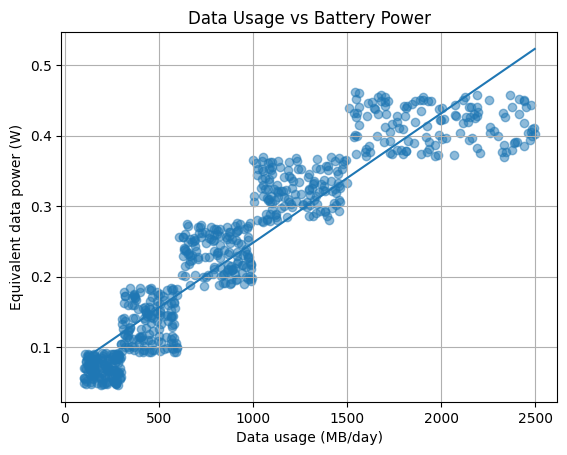

In [ ]:
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
y_pred = model.predict(x_line)

plt.scatter(X, y, alpha=0.5)
plt.plot(x_line, y_pred)
plt.xlabel("Data usage (MB/day)")
plt.ylabel("Equivalent data power (W)")
plt.title("Data Usage vs Battery Power")
plt.grid(True)
plt.show()


✅ File loaded successfully

📊 Data Statistics:
Number of samples: 700
X range: 102.0 ~ 2497.0
Y range: 302.0 ~ 2993.0

📌 Pearson correlation: 0.9323
📌 Linear fit: y = 1.1924x + 416.55

📌 SELECT YOUR INTERVAL
Enter LEFT boundary (min 102.0, max 2497.0): 150
Enter RIGHT boundary (min 151.0, max 2497.0): 300
✅ Your selected interval: 150.0 ~ 300.0 MB/day
📊 Points in interval: 100
🎯 Median point: (230.0, 458.0)


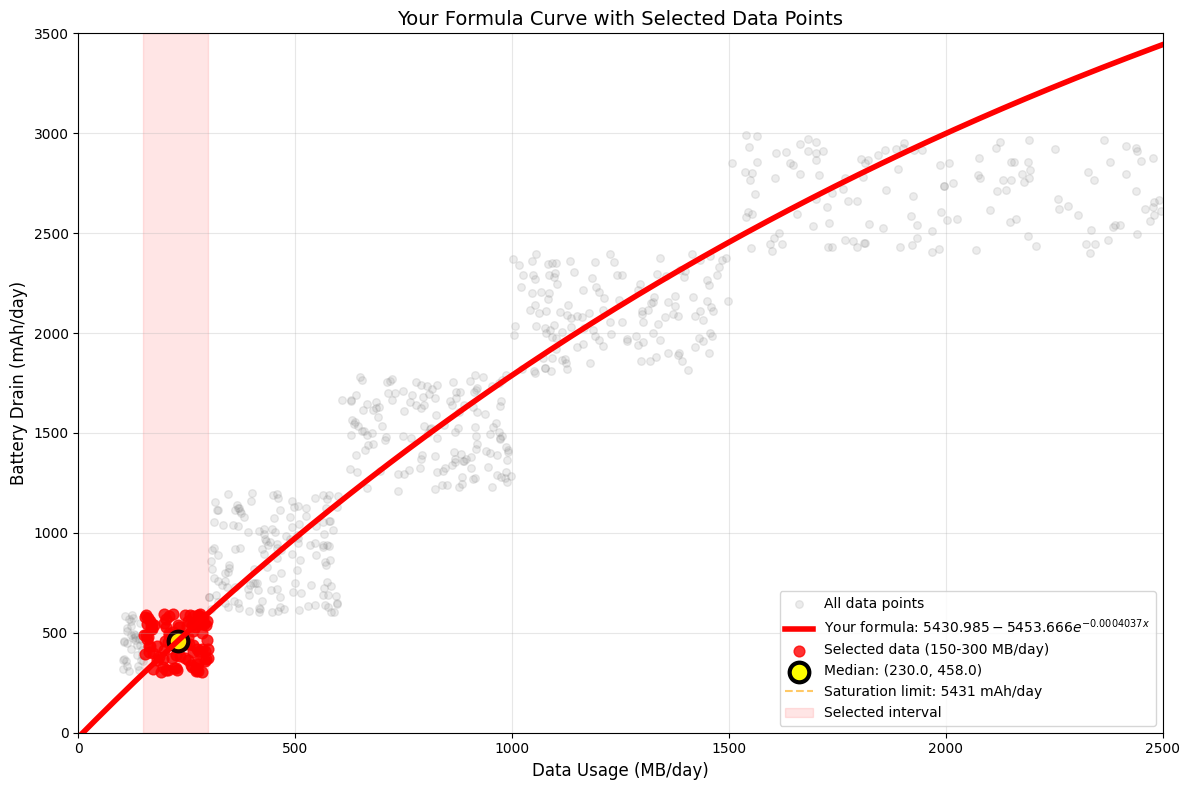


📊 ANALYSIS SUMMARY
Your interval: 150.0 ~ 300.0 MB/day
Points in interval: 100
Median point: X = 230.0, Y = 458.0

Your formula: P(x) = 5430.985 - 5453.666 * exp(-0.0004037 * x)
Saturation value: 5430.985 mAh/day
Initial value (x=0): -22.681 mAh/day


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
# import tkinter as tk
# from tkinter import simpledialog # Removed tkinter for headless environment

# =========================
# 1) Load your data file
# =========================
file_path = "MobileDeviceUsageexport2026-02-0102-59-00.csv"
df = pd.read_csv(file_path)
print("✅ File loaded successfully")

# =========================
# 2) Specify X and Y columns
# =========================
x_col = "Data Usage (MB/day)"
y_col = "Battery Drain (mAh/day)"

x = df[x_col].to_numpy(dtype=float)
y = df[y_col].to_numpy(dtype=float)

print(f"\n📊 Data Statistics:")
print(f"Number of samples: {len(x)}")
print(f"X range: {x.min():.1f} ~ {x.max():.1f}")
print(f"Y range: {y.min():.1f} ~ {y.max():.1f}")

# =========================
# 3) Basic statistics
# =========================
coef = np.polyfit(x, y, 1)
r_p, p_p = pearsonr(x, y)
print(f"\n📌 Pearson correlation: {r_p:.4f}")
print(f"📌 Linear fit: y = {coef[0]:.4f}x + {coef[1]:.2f}")

# =========================
# 4) Select interval using input() prompts
# =========================
print("\n" + "="*60)
print("📌 SELECT YOUR INTERVAL")
print("="*60)

# Replace simpledialog with input()
while True:
    try:
        left_bound_str = input(f"Enter LEFT boundary (min {x.min():.1f}, max {x.max():.1f}): ").strip()
        left_bound = float(left_bound_str)
        if not (x.min() <= left_bound <= x.max()):
            print("❌ Input out of valid range.")
            continue
        break
    except ValueError:
        print("❌ Invalid input. Please enter a number.")

while True:
    try:
        right_bound_str = input(f"Enter RIGHT boundary (min {left_bound + 1:.1f}, max {x.max():.1f}): ").strip()
        right_bound = float(right_bound_str)
        if not (left_bound + 1 <= right_bound <= x.max()):
            print("❌ Input out of valid range.")
            continue
        break
    except ValueError:
        print("❌ Invalid input. Please enter a number.")

selected_range = (left_bound, right_bound)
print(f"✅ Your selected interval: {selected_range[0]:.1f} ~ {selected_range[1]:.1f} MB/day")

# Filter data in the interval
mask = (x >= selected_range[0]) & (x <= selected_range[1])
x_selected = x[mask]
y_selected = y[mask]

print(f"📊 Points in interval: {len(x_selected)}")

if len(x_selected) > 0:
    x_median = float(np.median(x_selected))
    y_median = float(np.median(y_selected))
    print(f"🎯 Median point: ({x_median:.1f}, {y_median:.1f})")
else:
    print("⚠️ No data points in this interval!")
    x_median = None
    y_median = None

# =========================
# 5) Your formula
# =========================
def your_formula(x):
    """Your formula: P(x) = 5430.985 - 5453.666 * exp(-0.0004037 * x)"""
    return 5430.985 - 5453.666 * np.exp(-0.0004037 * x)

# =========================
# 6) Create single plot: Your formula curve
# =========================
plt.figure(figsize=(12, 8))

# Plot all data points
plt.scatter(x, y, alpha=0.15, s=30, color='gray', label="All data points")

# Plot your formula curve
x_curve = np.linspace(0, 2500, 500)
y_curve = your_formula(x_curve)
plt.plot(x_curve, y_curve, 'red', linewidth=4,
         label='Your formula: $5430.985 - 5453.666e^{-0.0004037x}$')

# Plot selected interval data points
if len(x_selected) > 0:
    plt.scatter(x_selected, y_selected, alpha=0.8, s=60, color='red',
                label=f'Selected data ({selected_range[0]:.0f}-{selected_range[1]:.0f} MB/day)')

# Plot median point
if x_median is not None:
    plt.scatter(x_median, y_median, s=200, color='yellow', edgecolors='black',
                linewidth=3, label=f'Median: ({x_median:.1f}, {y_median:.1f})')

# Add saturation line
saturation_value = 5430.985
plt.axhline(y=saturation_value, color='orange', linestyle='--', alpha=0.6,
            label=f'Saturation limit: {saturation_value:.0f} mAh/day')

# Highlight selected interval area
plt.axvspan(selected_range[0], selected_range[1], alpha=0.1, color='red',
            label=f'Selected interval')

# Plot settings
plt.xlabel(x_col, fontsize=12)
plt.ylabel(y_col, fontsize=12)
plt.title('Your Formula Curve with Selected Data Points', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)

# Set appropriate limits
plt.xlim(0, 2500)
plt.ylim(0, 3500)

plt.tight_layout()
plt.show()

# =========================
# 7) Print summary
# =========================
print("\n" + "="*60)
print("📊 ANALYSIS SUMMARY")
print("="*60)
print(f"Your interval: {selected_range[0]:.1f} ~ {selected_range[1]:.1f} MB/day")
print(f"Points in interval: {len(x_selected)}")
if x_median is not None:
    print(f"Median point: X = {x_median:.1f}, Y = {y_median:.1f}")
print(f"\nYour formula: P(x) = 5430.985 - 5453.666 * exp(-0.0004037 * x)")
print(f"Saturation value: {saturation_value:.3f} mAh/day")
print(f"Initial value (x=0): {your_formula(0):.3f} mAh/day")